# ESM-C layer sweep: vilip1 composite-hotspot design campaign (combined 45k)

Sweeps HDBSCAN clustering quality across all 31 ESM-C hidden-state layers (`layer_0` = embedding output before any transformer block, `layer_30` = final layer) on the same filtered pool, using the same HDBSCAN params already tuned on vilip1's original full-campaign pool (`min_cluster_size=4`, `min_samples=3`) -- held fixed across layers here so the sweep isolates the effect of layer depth, not re-tuned HDBSCAN parameters.

This is the **combined** composite-hotspot pool: the original `vilip1-design-composite_hotspot-20260724-v2` campaign (5000 designs, 50-150 aa binders) plus a new `vilip1-design-composite_hotspot-20260728` campaign (40000 designs, all 100-150 aa binders -- the length range found to work better) targeting the same composite hotspot epitope on vilip1. `data/vilip1-design-composite_hotspot-combined/` concatenates both campaigns' manifests and embeddings (ids/order verified to match 1:1 with `manifest_with_ipsae.csv` here). ipsae/ipae for the new 40k portion were computed the same way as v2 (`scripts/compute_ipsae.py`/`compute_ipae.py`) and merged into a matching `manifest_with_ipsae.csv` in the `-20260728` data dir before concatenation.

Goal: figure out whether embedding usefulness for clustering scales monotonically with depth or peaks somewhere in the middle, before spending time on the full UMAP/medoid/wet-lab-selection/structural-overlay pipeline on any particular layer -- same question as the v2-only sweep, now re-run on the much larger, length-homogeneous pool to see if the answer holds up.

Embeddings computed via `inference/embed_esmc.py --layers all` on Waluigi (one forward pass per batch; every hidden_states layer pooled from the same pass).


In [1]:
import os
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

## Filter to well-scored designs (same as final-layer notebook)

In [2]:
# Same thresholds as the v2-only sweep (iptm>0.7, ipsae>0.4, ipae<10.0) --
# see esmc_layer_sweep_vilip1_composite_hotspot.ipynb / esmc_deepdive_..._layer20.ipynb
# for how these were picked (v2's exact vilip1_full20k thresholds, iptm>0.7/
# ipsae>0.7/ipae<6.0, only passed 58/5000 -- too small a pool). On this combined
# 45k pool the same loosened thresholds pass 5372/45000 (~12%), consistent
# across both the v2 (591/5000, 11.8%) and 20260728 (4781/40000, 12.0%)
# portions -- a healthy, similarly-scored pool from both campaigns.

# NOTE: this notebook lives at notebooks/bridget/esmc_embedding_analysis/ --
# three directories deep from the repo root, so data paths need ../../../.
MANIFEST_PATH = "../../../data/vilip1-design-composite_hotspot-combined/manifest_with_ipsae.csv"
EMBEDDINGS_PATH = "../../../data/vilip1-design-composite_hotspot-combined/embeddings_all_layers.npz"
# Sweep outputs land in a layer_sweep/ subfolder so they don't clobber the
# final-layer analysis files already in clustering/.
OUTPUT_DIR = "../../../data/vilip1-design-composite_hotspot-combined/clustering/layer_sweep"
os.makedirs(OUTPUT_DIR, exist_ok=True)

manifest = pd.read_csv(MANIFEST_PATH)

IPTM_MIN = 0.7
IPSAE_MIN = 0.4
IPAE_MAX = 10.0

filtered_manifest = manifest[
    (manifest["iptm"] > IPTM_MIN)
    & (manifest["ipsae"] > IPSAE_MIN)
    & (manifest["ipae"] < IPAE_MAX)
].copy()

print(
    f"{len(filtered_manifest)}/{len(manifest)} designs pass " + f"iptm>{IPTM_MIN}, ipsae>{IPSAE_MIN}, ipae<{IPAE_MAX}"
)

filtered_ids = set(filtered_manifest["id"])


5372/45000 designs pass iptm>0.7, ipsae>0.4, ipae<10.0


## Load all-layer embeddings, restrict to filtered pool

In [3]:
npz = np.load(EMBEDDINGS_PATH, allow_pickle=True)
all_ids = npz["ids"]
keep_mask = np.array([eid in filtered_ids for eid in all_ids])
protein_names = all_ids[keep_mask].tolist()

layer_keys = sorted(
    [k for k in npz.files if k.startswith("layer_")],
    key=lambda k: int(k.split("_")[1]),
)
layer_indices = [int(k.split("_")[1]) for k in layer_keys]
print(f"Loaded {len(all_ids)} embeddings, kept {keep_mask.sum()} after filtering, {len(layer_keys)} layers ({layer_indices[0]}..{layer_indices[-1]})")

# L2-normalize each layer's filtered embeddings up front (HDBSCAN below runs
# euclidean distance, which on unit-norm vectors is equivalent to cosine --
# same convention as esmc_embedding_analysis_vilip1.ipynb).
X_by_layer = {
    idx: normalize(npz[f"layer_{idx}"][keep_mask], norm="l2", axis=1)
    for idx in layer_indices
}

Loaded 45000 embeddings, kept 5372 after filtering, 31 layers (0..30)


## Sweep HDBSCAN across every layer

In [4]:
MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 3

sweep_rows = []
for idx in layer_indices:
    X = X_by_layer[idx]
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean",
        prediction_data=True,
    )
    labels = clusterer.fit_predict(X)

    n_total = len(labels)
    n_noise = int(np.sum(labels == -1))
    unique_clusters = set(labels) - {-1}
    n_clusters = len(unique_clusters)

    non_noise = labels != -1
    if n_clusters >= 2 and non_noise.sum() >= 2:
        sil = silhouette_score(X[non_noise], labels[non_noise], metric="cosine")
    else:
        sil = float("nan")

    sweep_rows.append({
        "layer": idx,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_frac": n_noise / n_total,
        "silhouette": sil,
    })
    print(f"layer {idx:>2}: clusters={n_clusters:>3}  noise={n_noise:>5}/{n_total} ({n_noise/n_total:.1%})  silhouette={sil:.4f}")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(f"{OUTPUT_DIR}/layer_sweep_summary.csv", index=False)
print(f"\nSaved {OUTPUT_DIR}/layer_sweep_summary.csv")

layer  0: clusters=  4  noise= 1514/5372 (28.2%)  silhouette=0.4113


layer  1: clusters=  5  noise= 2576/5372 (48.0%)  silhouette=0.3900


layer  2: clusters=  4  noise= 1931/5372 (35.9%)  silhouette=0.4739


layer  3: clusters=  2  noise= 1849/5372 (34.4%)  silhouette=0.7350


layer  4: clusters=  4  noise= 1666/5372 (31.0%)  silhouette=0.4495


...

layer 26: clusters=  8  noise=  381/5372 (7.1%)  silhouette=0.6944


layer 27: clusters= 16  noise= 1418/5372 (26.4%)  silhouette=0.3528


layer 28: clusters= 12  noise= 1112/5372 (20.7%)  silhouette=0.3936


layer 29: clusters=  9  noise= 1248/5372 (23.2%)  silhouette=0.4842


layer 30: clusters= 10  noise= 1706/5372 (31.8%)  silhouette=0.3452

Saved ../../../data/vilip1-design-composite_hotspot-combined/clustering/layer_sweep/layer_sweep_summary.csv


## Plot clustering quality vs. layer depth

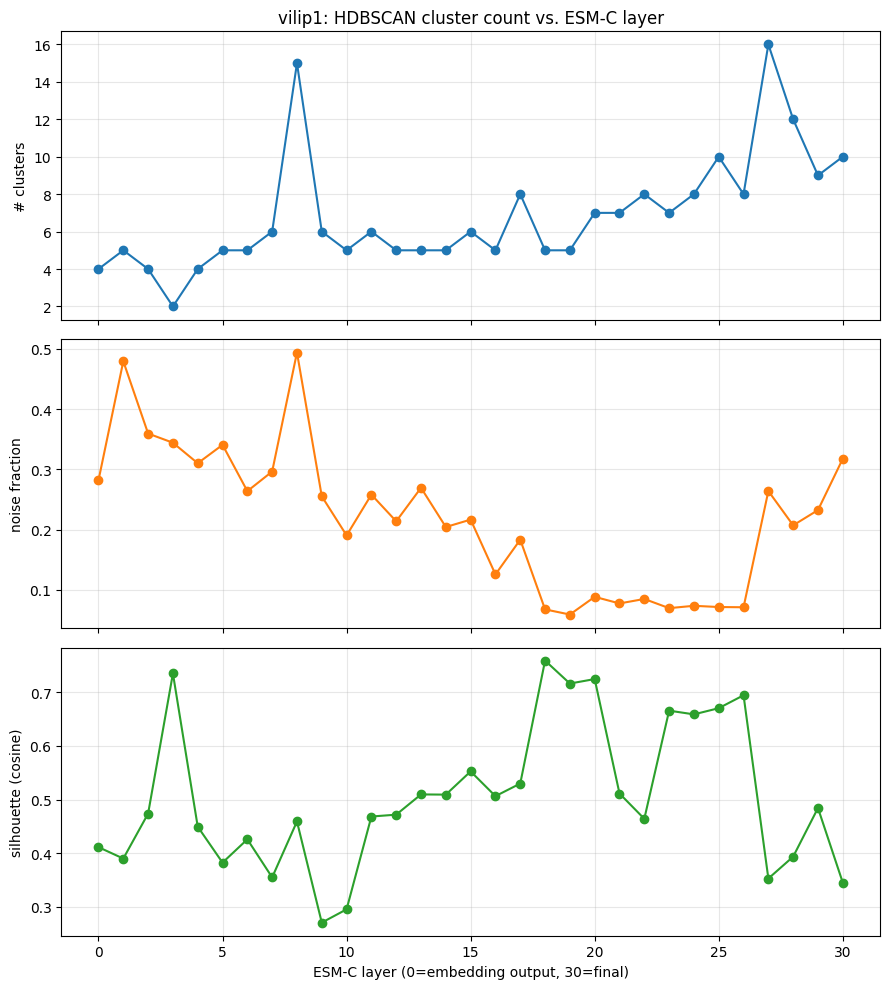

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(sweep_df["layer"], sweep_df["n_clusters"], marker="o")
axes[0].set_ylabel("# clusters")
axes[0].set_title("vilip1: HDBSCAN cluster count vs. ESM-C layer")

axes[1].plot(sweep_df["layer"], sweep_df["noise_frac"], marker="o", color="tab:orange")
axes[1].set_ylabel("noise fraction")

axes[2].plot(sweep_df["layer"], sweep_df["silhouette"], marker="o", color="tab:green")
axes[2].set_ylabel("silhouette (cosine)")
axes[2].set_xlabel("ESM-C layer (0=embedding output, 30=final)")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/layer_sweep.png", dpi=200)
plt.show()

## Candidate layers for the full deep-dive pipeline

In [6]:
# Ranks layers by silhouette among those that actually found >=2 clusters
# without collapsing to mostly noise (noise_frac < 0.5) -- a layer that puts
# everything in one cluster or calls everything noise isn't a useful
# clustering, whatever its silhouette says.
candidates = sweep_df[
    (sweep_df["n_clusters"] >= 2) & (sweep_df["noise_frac"] < 0.5)
].sort_values("silhouette", ascending=False)

print("Top candidate layers by silhouette (n_clusters>=2, noise<50%):")
print(candidates.head(10).to_string(index=False))

print("\nFinal layer (30) for reference:")
print(sweep_df[sweep_df["layer"] == 30].to_string(index=False))

Top candidate layers by silhouette (n_clusters>=2, noise<50%):
 layer  n_clusters  n_noise  noise_frac  silhouette
    18           5      362    0.067386    0.759019
     3           2     1849    0.344192    0.735000
    20           7      474    0.088235    0.724622
    19           5      316    0.058824    0.716255
    26           8      381    0.070923    0.694391
    25          10      383    0.071296    0.670329
    23           7      373    0.069434    0.665729
    24           8      394    0.073343    0.658813
    15           6     1163    0.216493    0.552496
    17           8      984    0.183172    0.529878

Final layer (30) for reference:
 layer  n_clusters  n_noise  noise_frac  silhouette
    30          10     1706    0.317573    0.345205
